In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd

In [2]:
from scipy import sparse
from anndata import AnnData
from pandas.api.types import CategoricalDtype
from matplotlib import pylab
import warnings
import socket
import yaml
from sklearn.cluster import DBSCAN
import holoviews as hv
import scvelo as scv
import seaborn as sns
import os
import sys
import scanpy.external as sce
import matplotlib as plt
import igraph
from fa2_modified import ForceAtlas2
import leidenalg

In [3]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()

scanpy==1.10.4 anndata==0.11.4 umap==0.5.7 numpy==2.2.6 scipy==1.15.2 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


In [4]:
outdir="saved/scanpy/"
adata = sc.read_h5ad(outdir+"mlo_with_new_annot_foetal.h5ad")

In [6]:
dimredDir="saved/scanpy/"

# Load the PCA embeddings (cells x PCs)
pca_emb = pd.read_csv(dimredDir+"pca_embeddings.csv", index_col=0)
# Load the PCA loadings (genes x PCs)
pca_load = pd.read_csv(dimredDir+"pca_loadings.csv", index_col=0)


# Load the PCA-corrected embeddings (cells x PCs)
har_emb = pd.read_csv(dimredDir+"harmony_embeddings.csv", index_col=0)
# Load the PCA-corrected loadings (genes x PCs)
har_load = pd.read_csv(dimredDir+"harmony_loadings.csv", index_col=0)


# Load the UMAP embeddings (cells x PCs)
umap_emb = pd.read_csv(dimredDir+"umap_embeddings.csv", index_col=0)


## loadings were not added because it's a subset of HVG and that creates a problem 

In [7]:
#Import highly variable genes
hvgenes = pd.read_csv(dimredDir+"HVG.csv", index_col=0)


In [8]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)


extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [9]:
seurat_hvg_list = hvgenes['VariableFeatures'].tolist()

adata.var["highly_variable_seurat"] = adata.var.index.isin(seurat_hvg_list)


In [10]:
hvg_mask = adata.var['highly_variable_seurat']
hvg_genes = adata.var_names[hvg_mask]
assert all(gene in pca_load.index for gene in hvg_genes), "Mismatch in gene names!"


In [11]:
pca_load_aligned = pca_load.loc[hvg_genes]


In [12]:
n_genes = adata.shape[1]
n_pcs = pca_load.shape[1]

# Initialize empty matrix with NaNs
full_loadings = np.full((n_genes, n_pcs), np.nan)

# Insert actual loadings at the right positions
full_loadings[hvg_mask.values, :] = pca_load_aligned.values

# Store in adata.varm
adata.varm['pca_loadings'] = full_loadings

In [13]:
# Align the cell order
pca_emb = pca_emb.loc[adata.obs_names]

# Add to AnnData
adata.obsm["X_pca"] = pca_emb.to_numpy()


In [14]:

har_emb = har_emb.loc[adata.obs_names]
umap_emb = umap_emb.loc[adata.obs_names]

adata.obsm["X_harmony"] = har_emb.to_numpy()
adata.obsm["X_umap"] = umap_emb.to_numpy()

In [15]:
#loadings from harmony
assert all(gene in har_load.index for gene in hvg_genes), "Mismatch in gene names!"
har_load_aligned = har_load.loc[hvg_genes]

n_genes = adata.shape[1]
n_pcs = har_load.shape[1]

In [16]:
# Initialize empty matrix with NaNs
full_loadings = np.full((n_genes, n_pcs), np.nan)

# Insert actual loadings at the right positions
full_loadings[hvg_mask.values, :] = har_load_aligned.values

# Store in adata.varm
adata.varm['harmony_loadings'] = full_loadings

In [17]:
adata.var

,vst.mean,vst.variance,vst.variance.expected,vst.variance.standardized,vst.variable,highly_variable,means,dispersions,dispersions_norm,highly_variable_seurat
AL627309.1,0.002212,0.002207,0.002570,0.858657,0,False,0.003343,0.789329,0.059290,False
AL669831.5,0.146640,0.225052,0.201006,1.119626,0,False,0.078962,0.696171,-0.319129,False
FAM87B,0.002191,0.002633,0.002544,1.034806,0,False,0.002798,0.664829,-0.446445,False
LINC00115,0.029158,0.031960,0.041001,0.779507,0,False,0.041975,0.746296,-0.115513,False
FAM41C,0.013757,0.014055,0.018996,0.739875,0,False,0.024378,0.616596,-0.642377,False
...,...,...,...,...,...,...,...,...,...,...
AC007325.4,0.132071,0.161422,0.180908,0.892285,0,False,0.133852,0.678376,-0.391417,False
AC007325.2,0.003673,0.003984,0.004424,0.900504,0,False,0.016477,0.860391,0.347953,False
AL354822.1,0.001380,0.001378,0.001535,0.897723,0,False,0.001156,0.814428,0.161248,False
AC004556.1,0.053912,0.060381,0.074760,0.807663,0,False,0.142482,0.653554,-0.492245,False


In [18]:
pd.crosstab(adata.var['highly_variable'], adata.var['highly_variable_seurat'])

highly_variable_seurat,False,True
highly_variable,,
False,19129,903
True,903,1097


In [19]:
celltype_colors = {
    "Astrocytes": "#e41a1c",
    "Early Midbrain Prog": "#fa8841",
    "Late Midbrain Prog": "#7e6e85",
    "Neuron Prog": "#e1c62f",
    "Highly prolif NSC": "#b75f49",
    "Immature Neurons": "#48a462",
    "Mature Neurons": "#48d1cc",
    "Microglia": "#4a72a6",
    "Perivascular cells": "#ec83ba",
    "Others": "#1a1a1a"
}

In [20]:
adata.obs["lowRes"] = adata.obs["lowRes"].astype("category")
adata.uns["lowRes_colors"] = [celltype_colors[ct] for ct in adata.obs["lowRes"].cat.categories]

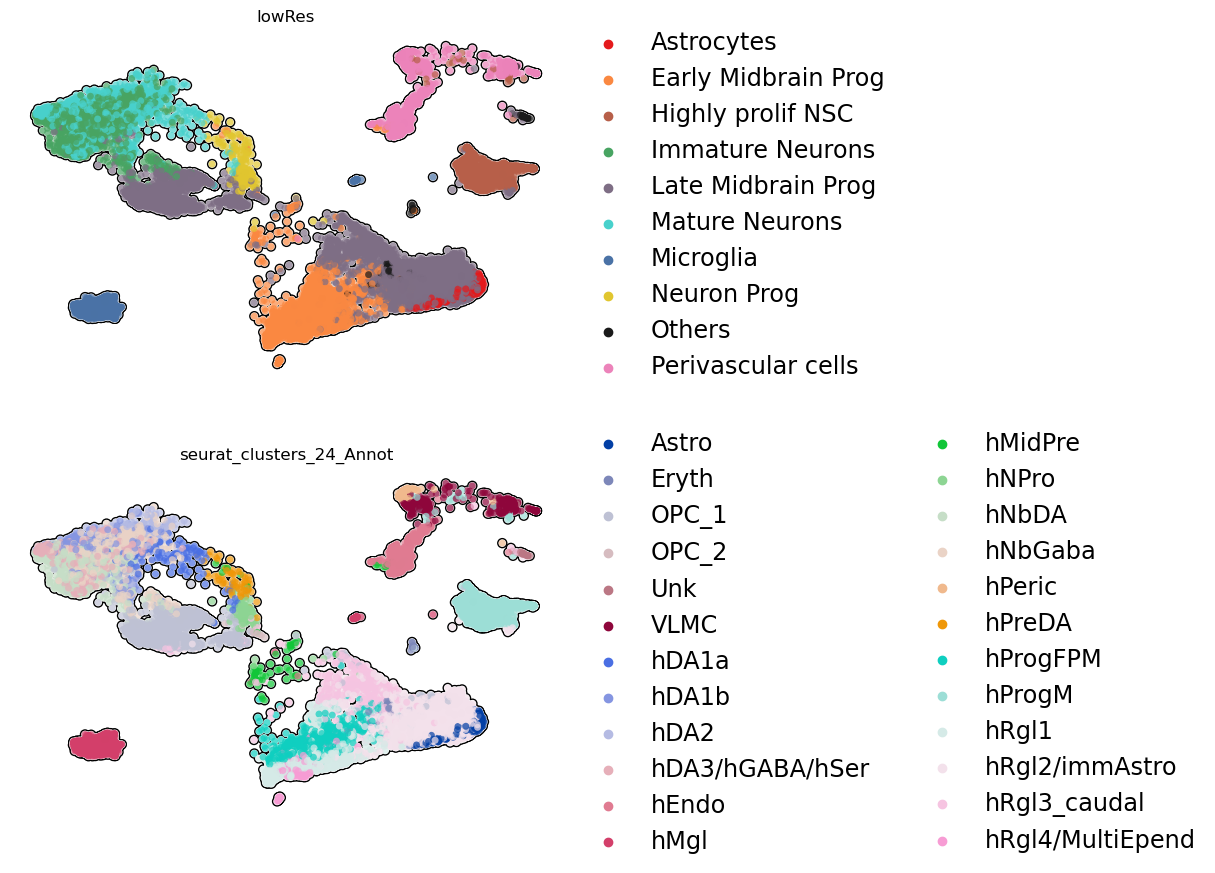

In [21]:
sc.pl.umap(adata, color=list(set(['seurat_clusters_24_Annot',"lowRes"])), size = 100,add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98', wspace=.2, ncols=1, frameon=False, legend_fontsize="xx-large")

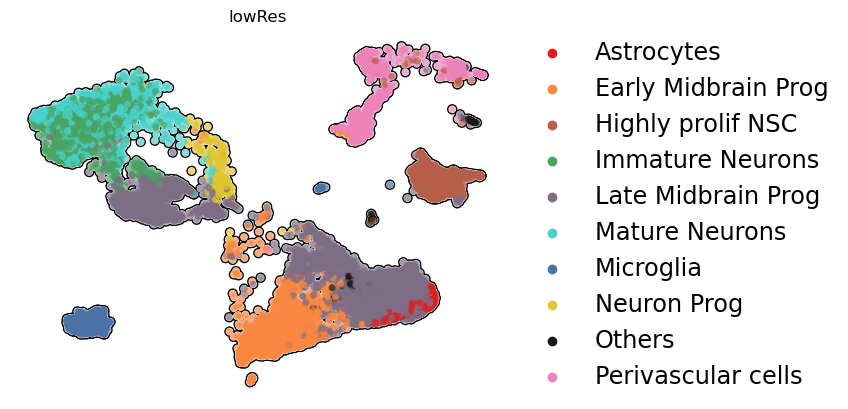

In [22]:
sc.pl.umap(adata, color="lowRes",
           size = 100,add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98',
           wspace=.2, ncols=1, frameon=False, legend_fontsize="xx-large",
          save="suppFigure9A.svg")

In [23]:
sc.pp.neighbors(adata, use_rep='X_harmony')

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:20)


In [24]:
sc.tl.draw_graph(adata)

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:02:32)


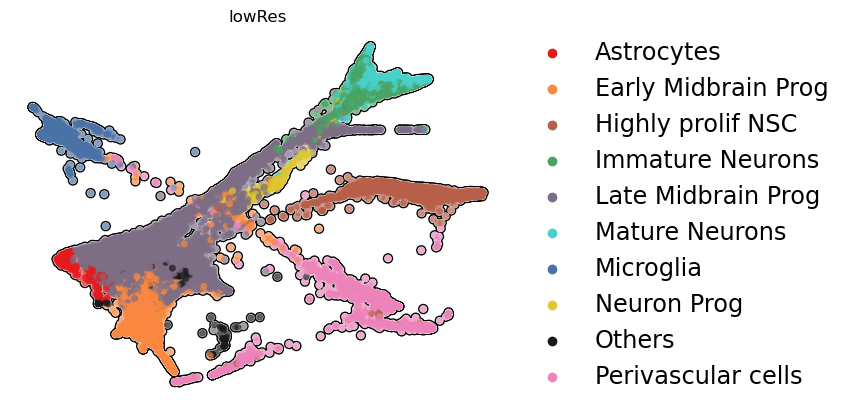

In [25]:
sc.pl.draw_graph(adata,color=["lowRes"], 
                 size = 100,add_outline=True, 
                 outline_width=(0.2, 0.05),
                 vmin='p2',vmax='p98', wspace=.2, ncols=1,
                 frameon=False, legend_fontsize="xx-large",
                save="suppFigure9B.svg")

In [26]:
print("Taking the overall annotation")

Taking the overall annotation


In [27]:
sc.tl.paga(adata, groups="lowRes", use_rna_velocity=False)

groups="lowRes"
basis="X_draw_graph_fa"
if 'embeddings' in globals():
    del embeddings
for l in adata.obs[groups].cat.categories:
    test=adata.obsm[basis][adata.obs[groups] == l]
    x=np.mean(test[:,0])
    y=np.mean(test[:,1])
    if not 'embeddings' in globals():
        embeddings = np.array([x,y])
    else:
        embeddings=np.vstack([embeddings,np.array([x,y])])


running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


In [28]:
print("Taking subclustering")

Taking subclustering


running Leiden clustering
    finished: found 31 clusters and added
    'leiden_1', the cluster labels (adata.obs, categorical) (0:00:08)
running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


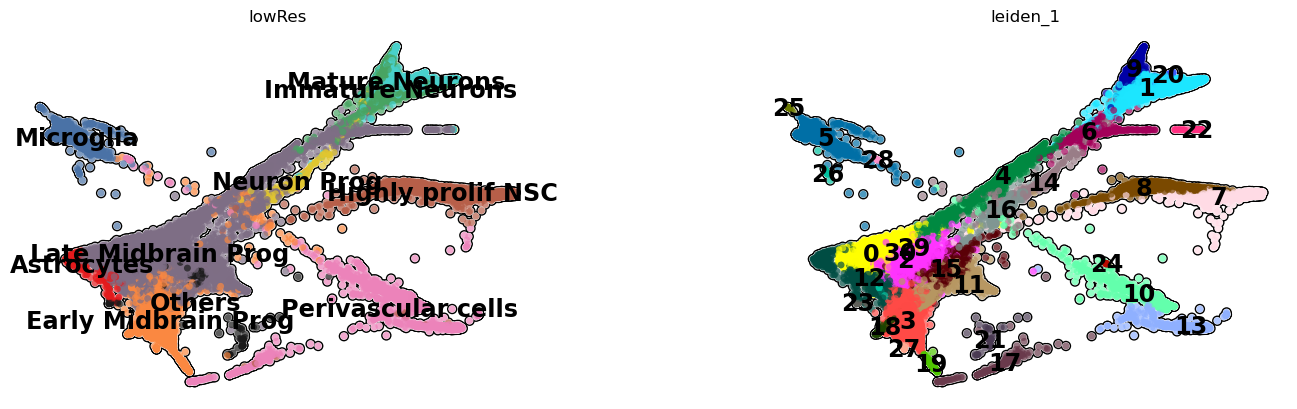

--> added 'pos', the PAGA positions (adata.uns['paga'])


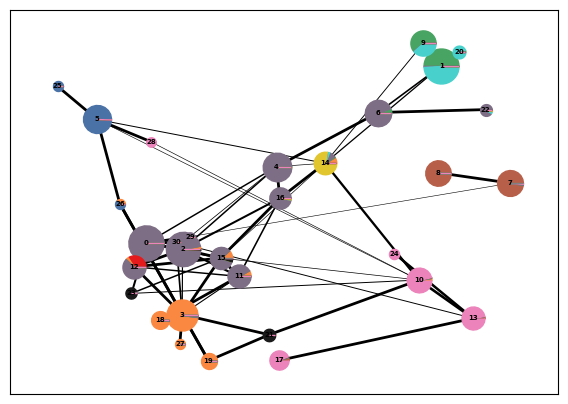

In [29]:
adataPaga = adata.copy()

leidenres = 1

sc.tl.leiden(adataPaga, resolution=leidenres, key_added="leiden_"+str(leidenres))

sc.tl.paga(adataPaga, groups="leiden_"+str(leidenres), use_rna_velocity=False)

groups="leiden_"+str(leidenres)
basis="X_draw_graph_fa"
if 'embeddings' in globals():
    del embeddings
for l in adataPaga.obs[groups].cat.categories:
    test=adataPaga.obsm[basis][adataPaga.obs[groups] == l]
    x=np.mean(test[:,0])
    y=np.mean(test[:,1])
    if not 'embeddings' in globals():
        embeddings = np.array([x,y])
    else:
        embeddings=np.vstack([embeddings,np.array([x,y])])

sc.pl.draw_graph(adataPaga, color = ["lowRes","leiden_"+str(leidenres)],ncols=2, 
           size = 100,add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98', legend_fontsize="xx-large", frameon=False, wspace=.3, legend_loc="on data")

thresholdPagaEdges = 0.05
sc.pl.paga(adataPaga, pos=embeddings, max_edge_width=2, threshold = thresholdPagaEdges, color = "lowRes", node_size_scale=2, save="suppFigure9C.svg", fontsize=5)

In [30]:
pd.crosstab(adataPaga.obs["lowRes"],adataPaga.obs["leiden_"+str(leidenres)]) / pd.crosstab(adataPaga.obs["lowRes"],adataPaga.obs["leiden_"+str(leidenres)]).sum(axis = 0)


leiden_1,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
lowRes,,,,,,,,,,,,,,,,,,,,,
Astrocytes,0.002061,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
Early Midbrain Prog,0.007901,0.001806,0.031274,0.979522,0.000000,0.006055,0.000000,0.000000,0.000000,0.000000,...,0.022222,0.000000,0.000000,0.0,0.0,0.388889,1.0,0.0,0.0,0.0
Highly prolif NSC,0.000344,0.000000,0.000000,0.000000,0.000797,0.000000,0.001096,0.978648,0.997468,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
Immature Neurons,0.000000,0.496749,0.000000,0.000000,0.011952,0.000000,0.058114,0.000000,0.000000,0.608579,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
Late Midbrain Prog,0.989007,0.010477,0.961861,0.019909,0.986454,0.000000,0.936404,0.010676,0.001266,0.005362,...,0.000000,0.916667,0.068966,0.0,0.0,0.000000,0.0,0.0,1.0,1.0
Mature Neurons,0.000000,0.488439,0.000000,0.000000,0.000000,0.000000,0.003289,0.000000,0.000000,0.386059,...,0.000000,0.055556,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
Microglia,0.000000,0.000000,0.000381,0.000000,0.000000,0.987889,0.000000,0.000000,0.001266,0.000000,...,0.000000,0.000000,0.000000,0.0,1.0,0.611111,0.0,0.0,0.0,0.0
Neuron Prog,0.000000,0.002529,0.000000,0.000000,0.000797,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.027778,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
Others,0.000687,0.000000,0.006484,0.000569,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.977778,0.000000,0.931034,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [31]:
import networkx as nx
testGraph = nx.from_numpy_array(adataPaga.uns["paga"]["connectivities"].todense(), parallel_edges=False, create_using=None )
testGraph.remove_edges_from([(n1, n2) for n1, n2, w in testGraph.edges(data="weight") if w < thresholdPagaEdges])
for t in testGraph.edges(data="weight"):
    testGraph[t[0]][t[1]]["weight"] = 1-t[2]

[3, 18, 11, 15, 16, 14, 1, 20]


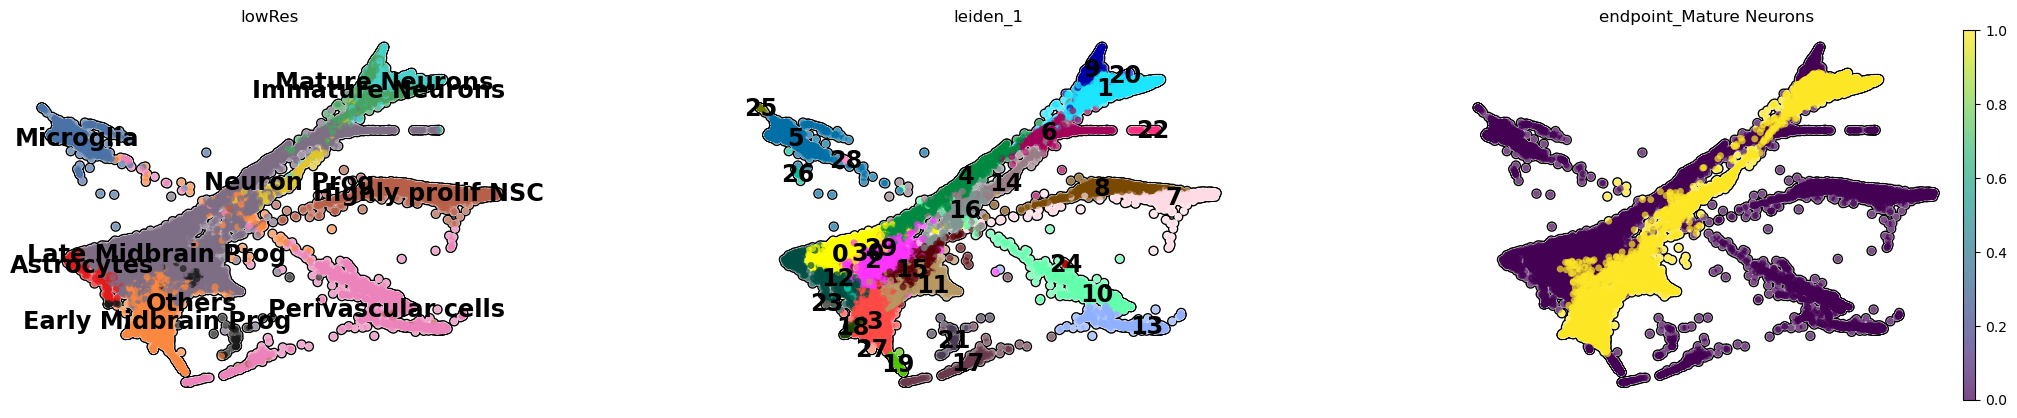

In [32]:
endpoint="Mature Neurons"
sp = nx.shortest_path(testGraph, source=3, target=20, weight="weight", method='bellman-ford')
print(sp)
adataPaga.obs["endpoint_"+str(endpoint)] = adataPaga.obs["leiden_"+str(leidenres)].astype(int).isin(sp).astype(int)
sc.pl.draw_graph(adataPaga, color = ["lowRes","leiden_"+str(leidenres),"endpoint_"+str(endpoint)],ncols=3, 
                 size = 100,add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98',
                 legend_fontsize="xx-large", frameon=False, wspace=.3, legend_loc="on data", save="/endpoint_neuroDA_3cols.pdf")

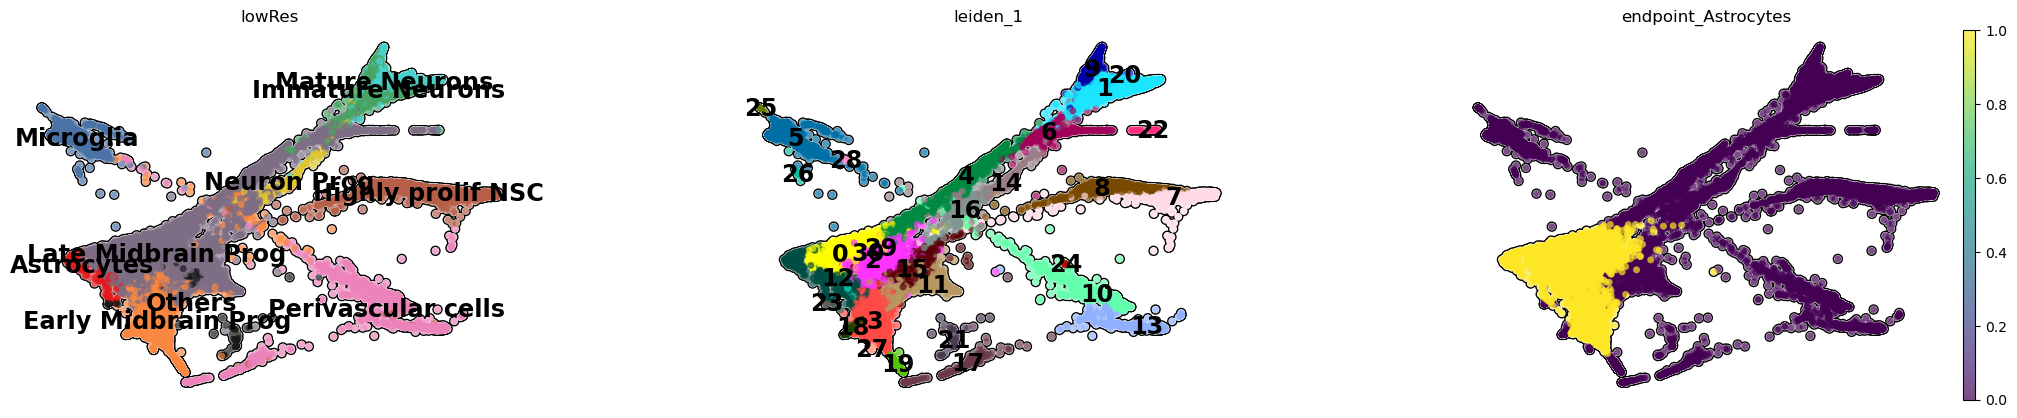

In [33]:
endpoint="Astrocytes"
sp1 = nx.shortest_path(testGraph, source=3, target=0, weight="weight", method='bellman-ford')
sp2 = nx.shortest_path(testGraph, source=0, target=12, weight="weight", method='bellman-ford')
sp = sp1 + sp2[1:]
adataPaga.obs["endpoint_"+str(endpoint)] = adataPaga.obs["leiden_"+str(leidenres)].astype(int).isin(sp).astype(int)
sc.pl.draw_graph(adataPaga, color = ["lowRes","leiden_"+str(leidenres),"endpoint_"+str(endpoint)],ncols=3, 
                 size = 100,add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98',
                 legend_fontsize="xx-large", frameon=False, wspace=.3, legend_loc="on data", save="/endpoint_astro_3cols.pdf")

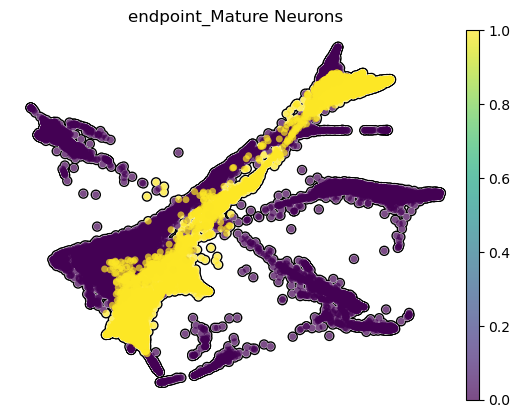

In [34]:
sc.pl.draw_graph(adataPaga, color = ["endpoint_Mature Neurons"],
           size = 100,add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98', legend_fontsize="xx-large", 
                 frameon=False,  legend_loc="on data", save="/mainFigure3I_bottom.svg")

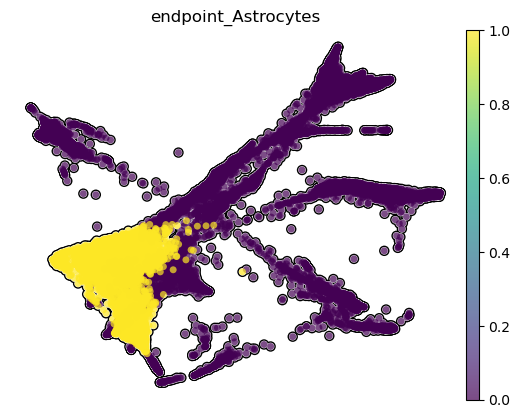

In [35]:
sc.pl.draw_graph(adataPaga, color = ["endpoint_Astrocytes"],
           size = 100,add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98', legend_fontsize="xx-large", 
                 frameon=False,  legend_loc="on data", save="/mainFigure3I_upper.svg")

In [36]:
adataPaga.write_h5ad(filename=outdir+"mlo_with_new_annot_wPaga_foetal.h5ad")